# 🫁 Phase 1.1v4: Enhanced Image Classifier — Cross-Val + TTA (PA Viewpoint)

### Upgrades over v3:
1. **5-Fold Patient-Level Cross-Validation** (`GroupKFold` on `subject_id`) — robust metrics across all data
2. **Test Time Augmentation (TTA)** — average predictions over 10 augmented versions of each test image

### Retained from v3:
- DenseNet121 CXR-pretrained backbone (`torchxrayvision`)
- CLAHE preprocessing + Lung ROI cropping
- CBAM attention
- Focal Loss (γ=2) + 2× pneumonia class weight
- Mixup augmentation (α=0.3) + Label smoothing (0.1)
- Safe augmentations only (no horizontal flip)
- Differential learning rates
- Youden's J threshold tuning per fold

In [1]:
# --- CELL 0: Imports & Reproducibility ---
import os, random, warnings, copy, json as json_lib
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from torchvision import transforms
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score, auc,
    precision_recall_curve, average_precision_score
)

import torchxrayvision as xrv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('Memory:', torch.cuda.get_device_properties(DEVICE).total_memory / 1e9, 'GB')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Memory: 4.294508544 GB


In [2]:
# --- CELL 1: Paths & Hyperparameters ---
BASE_DIR   = r'c:\2026\PneumoFusionNet\mimic\main\dataset'
CSV_PATH   = os.path.join(BASE_DIR, 'mimic_paired_dataset.csv')
SAVE_DIR   = os.path.join(BASE_DIR, 'outputs', 'Phase_1.1v4_PA_crossval_scaleup')
BBOX_CSV   = os.path.join(BASE_DIR, 'outputs', 'Phase_1_Scaleup_PA_v2', 'lung_bboxes_scaleup_v2.csv')

IMG_SIZE       = 224
BATCH_SIZE     = 8
NUM_EPOCHS     = 20
LR             = 3e-5
WEIGHT_DECAY   = 1e-4
NUM_CLASSES    = 2
WARMUP_EPOCHS  = 5
GRAD_CLIP      = 1.0
PATIENCE       = 6
MIXUP_ALPHA    = 0.3
LABEL_SMOOTH   = 0.1
PNEUMONIA_WT   = 2.0
N_FOLDS        = 5
TTA_TRANSFORMS = 10  # Number of augmented views for TTA

CLASSES = ['NORMAL', 'PNEUMONIA']
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save dir    : {SAVE_DIR}')
print(f'Folds       : {N_FOLDS}')
print(f'TTA views   : {TTA_TRANSFORMS}')
print(f'Epochs/fold : {NUM_EPOCHS}')

Save dir    : c:\2026\PneumoFusionNet\mimic\main\dataset\outputs\Phase_1.1v4_PA_crossval_scaleup
Folds       : 5
TTA views   : 10
Epochs/fold : 20


In [3]:
# --- CELL 2: Data Loading & Filtering ---
df = pd.read_csv(CSV_PATH)

def resolve_data_path(path):
    if pd.isna(path) or str(path).strip() == '':
        return ''
    path = str(path).replace('/', os.sep).replace('\\', os.sep)
    return path if os.path.isabs(path) else os.path.join(BASE_DIR, path)

df['image_path'] = df['image_path'].apply(resolve_data_path)
df['label'] = np.select(
    [df['pneumonia_label'].eq(1.0), df['no_finding_label'].eq(1.0)],
    [1, 0], default=-1
)
df = df[(df['label'] >= 0) & df['view_position'].eq('PA')].copy()
df['label_name'] = df['label'].map({0: 'Normal', 1: 'Pneumonia'})

# Balance
n_per_class = int(df['label'].value_counts().min())
normal_df    = df[df['label'] == 0].sample(n=n_per_class, random_state=SEED)
pneumonia_df = df[df['label'] == 1].sample(n=n_per_class, random_state=SEED)
df = pd.concat([normal_df, pneumonia_df]).sample(frac=1, random_state=SEED).reset_index(drop=True)

missing = df['image_path'].apply(lambda p: not os.path.exists(p)).sum()
print(f'Total: {len(df)} | Per class: {n_per_class} | Missing: {missing}')

Total: 3744 | Per class: 1872 | Missing: 0


In [4]:
# --- CELL 3: Lung Bounding Boxes ---
from tqdm import tqdm

def compute_lung_bbox(image_path, margin=10):
    try:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None: return None
        h, w = img.shape
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img_eq = clahe.apply(img)
        blurred = cv2.GaussianBlur(img_eq, (5, 5), 0)
        _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours: return None
        min_area = h * w * 0.05
        lung_contours = [c for c in contours if cv2.contourArea(c) > min_area]
        if not lung_contours:
            cx, cy = w // 2, h // 2
            crop_w, crop_h = int(w * 0.8), int(h * 0.8)
            return (cx - crop_w//2, cy - crop_h//2, cx + crop_w//2, cy + crop_h//2)
        all_points = np.vstack(lung_contours)
        x, y, bw, bh = cv2.boundingRect(all_points)
        return (max(0, x-margin), max(0, y-margin), min(w, x+bw+margin), min(h, y+bh+margin))
    except: return None

BBOX_CSV_V4 = os.path.join(SAVE_DIR, 'lung_bboxes.csv')
if os.path.exists(BBOX_CSV):
    bbox_df = pd.read_csv(BBOX_CSV)
    print(f'Reusing v2 bboxes: {BBOX_CSV}')
elif os.path.exists(BBOX_CSV_V4):
    bbox_df = pd.read_csv(BBOX_CSV_V4)
else:
    print('Computing lung bounding boxes...')
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        bbox = compute_lung_bbox(row['image_path'])
        if bbox:
            records.append({'image_path': row['image_path'], 'x_min': bbox[0], 'y_min': bbox[1], 'x_max': bbox[2], 'y_max': bbox[3]})
        else:
            records.append({'image_path': row['image_path'], 'x_min': 0, 'y_min': 0, 'x_max': -1, 'y_max': -1})
    bbox_df = pd.DataFrame(records)
    bbox_df.to_csv(BBOX_CSV_V4, index=False)

bbox_lookup = bbox_df.set_index('image_path').to_dict('index')
print(f'Bboxes loaded: {len(bbox_lookup)}')

Reusing v2 bboxes: c:\2026\PneumoFusionNet\mimic\main\dataset\outputs\Phase_1_Scaleup_PA_v2\lung_bboxes_scaleup_v2.csv
Bboxes loaded: 3763


In [5]:
# --- CELL 4: Compute Normalization Stats ---
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
means, stds = [], []
for idx in range(min(len(df), 200)):
    try:
        img = cv2.imread(df.iloc[idx]['image_path'], cv2.IMREAD_GRAYSCALE)
        img = clahe.apply(img)
        bb = bbox_lookup.get(df.iloc[idx]['image_path'], None)
        if bb and bb['x_max'] > 0:
            img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
        img_arr = np.array(img, dtype=np.float32) / 255.0
        means.append(img_arr.mean())
        stds.append(img_arr.std())
    except: continue
MEAN = [np.mean(means)]
STD  = [np.mean(stds)]
print(f'MEAN: {MEAN[0]:.4f} | STD: {STD[0]:.4f}')

MEAN: 0.4984 | STD: 0.2740


In [6]:
# --- CELL 5: Transforms (Train / Val / TTA) ---

train_tfm = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomRotation(5),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),
])

val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# TTA transforms — diverse but medically safe augmentations
tta_transforms = [
    val_tfm,  # 0: Original (no augmentation)
    transforms.Compose([  # 1: Slight rotation +5
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation((5, 5)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]),
    transforms.Compose([  # 2: Slight rotation -5
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation((-5, -5)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]),
    transforms.Compose([  # 3: Zoom in
        transforms.Resize((256, 256)),
        transforms.CenterCrop(210),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]),
    transforms.Compose([  # 4: Slight brightness up
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(brightness=0.15),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]),
    transforms.Compose([  # 5: Slight contrast
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(contrast=0.15),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]),
    transforms.Compose([  # 6: Slight translate
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]),
    transforms.Compose([  # 7: Rotation +3
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation((3, 3)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]),
    transforms.Compose([  # 8: Rotation -3
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation((-3, -3)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]),
    transforms.Compose([  # 9: Gaussian blur
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.3, 0.5)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]),
]

print(f'Train transform: safe augmentations (no hflip)')
print(f'TTA transforms : {len(tta_transforms)} views')

Train transform: safe augmentations (no hflip)
TTA transforms : 10 views


In [7]:
# --- CELL 6: Dataset Class ---
class EnhancedCXRDataset(Dataset):
    def __init__(self, df, bbox_lookup, transform=None):
        self.df = df.reset_index(drop=True)
        self.bbox_lookup = bbox_lookup
        self.transform = transform
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)
        img = self.clahe.apply(img)
        bb = self.bbox_lookup.get(row.image_path, None)
        if bb and bb['x_max'] > 0:
            img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, int(row.label)

    def set_transform(self, transform):
        """Allows swapping transform for TTA."""
        self.transform = transform

print('EnhancedCXRDataset defined (with set_transform for TTA).')

EnhancedCXRDataset defined (with set_transform for TTA).


In [8]:
# --- CELL 7: CBAM + Focal Loss + Mixup (same as v3) ---

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return x * self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True)[0]
        return x * self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention()
    def forward(self, x):
        return self.spatial_att(self.channel_att(x))

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.label_smoothing = label_smoothing
    def forward(self, logits, targets):
        num_classes = logits.shape[1]
        if self.label_smoothing > 0:
            smooth = torch.zeros_like(logits).fill_(self.label_smoothing / (num_classes - 1))
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)
        else:
            smooth = F.one_hot(targets, num_classes).float()
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)
        focal_weight = (1.0 - probs) ** self.gamma
        loss = -focal_weight * smooth * log_probs
        if self.alpha is not None:
            loss = loss * self.alpha.to(logits.device).unsqueeze(0)
        return loss.sum(dim=1).mean()

def mixup_data(x, y, alpha=0.3):
    lam = max(np.random.beta(alpha, alpha), 1 - np.random.beta(alpha, alpha)) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print('CBAM, FocalLoss, Mixup defined.')

CBAM, FocalLoss, Mixup defined.


In [9]:
# --- CELL 8: Model Factory ---
def build_model():
    """Create a fresh model for each fold."""
    class EnhancedPneumoNetV4(nn.Module):
        def __init__(self):
            super().__init__()
            xrv_model = xrv.models.DenseNet(weights='densenet121-res224-all')
            self.features = xrv_model.features
            freeze_layers = {'conv0','norm0','relu0','pool0','denseblock1','transition1','denseblock2','transition2'}
            for name, child in self.features.named_children():
                for p in child.parameters():
                    p.requires_grad = name not in freeze_layers
            self.cbam = CBAM(1024, reduction=16)
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.classifier = nn.Sequential(
                nn.Dropout(0.5), nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
                nn.Dropout(0.3), nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
                nn.Dropout(0.2), nn.Linear(128, NUM_CLASSES)
            )
        def forward(self, x):
            f = F.relu(self.features(x), inplace=True)
            f = self.cbam(f)
            f = self.pool(f).flatten(1)
            return self.classifier(f)
        def get_features(self, x):
            f = F.relu(self.features(x), inplace=True)
            f = self.cbam(f)
            return self.pool(f).flatten(1)

    model = EnhancedPneumoNetV4().to(DEVICE)
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Params: {total:,} total, {trainable:,} trainable ({trainable/total*100:.1f}%)')
    return model

# Smoke test
print('Building model...')
_m = build_model()
_d = torch.randn(2, 1, 224, 224).to(DEVICE)
print(f'  Output: {_m(_d).shape}, Features: {_m.get_features(_d).shape}')
del _m, _d
torch.cuda.empty_cache()

Building model...
  Params: 7,670,756 total, 6,247,396 trainable (81.4%)
  Output: torch.Size([2, 2]), Features: torch.Size([2, 1024])


In [10]:
# --- CELL 9: Training + Evaluation Functions ---

def train_one_epoch(model, loader, criterion, optimizer, device, mixup_alpha):
    model.train()
    total_loss = total_correct = total_n = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        mixed, ya, yb, lam = mixup_data(imgs, labels, mixup_alpha)
        optimizer.zero_grad()
        out = model(mixed)
        loss = mixup_criterion(criterion, out, ya, yb, lam)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        total_loss += loss.item() * len(labels)
        preds = out.argmax(1)
        total_correct += (lam * (preds == ya).float().sum().item() +
                          (1 - lam) * (preds == yb).float().sum().item())
        total_n += len(labels)
    return total_loss / total_n, total_correct / total_n

def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out = model(imgs)
            probs = F.softmax(out, dim=1)[:, 1]
            all_preds.extend(out.argmax(1).cpu().tolist())
            all_labels.extend(labels.tolist())
            all_probs.extend(probs.cpu().tolist())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    try: auc_val = roc_auc_score(all_labels, all_probs)
    except: auc_val = 0.0
    return acc, auc_val, f1, all_preds, all_labels, all_probs

def evaluate_tta(model, dataset, tta_tfms, device, batch_size=32):
    """Test Time Augmentation: average probabilities over multiple augmented views."""
    model.eval()
    n_samples = len(dataset)
    n_views = len(tta_tfms)
    all_probs = np.zeros((n_samples, n_views))
    all_labels = []

    for v, tfm in enumerate(tta_tfms):
        dataset.set_transform(tfm)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        probs_v = []
        labels_v = []
        with torch.no_grad():
            for imgs, labels in loader:
                out = model(imgs.to(device))
                p = F.softmax(out, dim=1)[:, 1].cpu().numpy()
                probs_v.extend(p)
                labels_v.extend(labels.tolist())
        all_probs[:, v] = probs_v
        if v == 0:
            all_labels = labels_v

    # Average across TTA views
    avg_probs = all_probs.mean(axis=1)
    avg_preds = (avg_probs >= 0.5).astype(int)

    acc = accuracy_score(all_labels, avg_preds)
    f1  = f1_score(all_labels, avg_preds, average='macro')
    try: auc_val = roc_auc_score(all_labels, avg_probs)
    except: auc_val = 0.0
    return acc, auc_val, f1, avg_preds.tolist(), all_labels, avg_probs.tolist()

def find_optimal_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    youden_j = tpr - fpr
    idx = np.argmax(youden_j)
    return thresholds[idx]

print('Training, Evaluation, TTA, Threshold functions defined.')

Training, Evaluation, TTA, Threshold functions defined.


In [11]:
# --- CELL 10: 5-Fold Cross-Validation Loop ---
gkf = GroupKFold(n_splits=N_FOLDS)
groups = df['subject_id'].values
labels_array = df['label'].values

fold_results = []  # Store per-fold metrics
all_test_labels = []
all_test_probs  = []
all_test_probs_tta = []
all_test_labels_tta = []

print('='*90)
print(f'5-FOLD PATIENT-LEVEL CROSS-VALIDATION')
print('='*90)

for fold, (train_idx, test_idx) in enumerate(gkf.split(df, labels_array, groups)):
    print(f'\n{"="*90}')
    print(f'FOLD {fold+1}/{N_FOLDS}')
    print(f'{"="*90}')

    train_df_fold = df.iloc[train_idx].reset_index(drop=True)
    test_df_fold  = df.iloc[test_idx].reset_index(drop=True)

    # Split train into train/val (80/20)
    from sklearn.model_selection import GroupShuffleSplit
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED + fold)
    tr_idx, va_idx = next(gss.split(train_df_fold, groups=train_df_fold['subject_id']))
    val_df_fold   = train_df_fold.iloc[va_idx].reset_index(drop=True)
    train_df_fold = train_df_fold.iloc[tr_idx].reset_index(drop=True)

    n_tr = len(train_df_fold); n_va = len(val_df_fold); n_te = len(test_df_fold)
    print(f'  Train: {n_tr} | Val: {n_va} | Test: {n_te}')
    print(f'  Train labels: {dict(Counter(train_df_fold["label"].values))}')
    print(f'  Test  labels: {dict(Counter(test_df_fold["label"].values))}')

    # Dataloaders
    tr_labels = train_df_fold['label'].values
    cls_counts = np.bincount(tr_labels)
    sw = [1.0 / cls_counts[l] for l in tr_labels]
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

    train_loader = DataLoader(EnhancedCXRDataset(train_df_fold, bbox_lookup, train_tfm),
                              batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, drop_last=True)
    val_loader   = DataLoader(EnhancedCXRDataset(val_df_fold, bbox_lookup, val_tfm),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_dataset = EnhancedCXRDataset(test_df_fold, bbox_lookup, val_tfm)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Build fresh model
    model = build_model()
    class_weights = torch.tensor([1.0, PNEUMONIA_WT], dtype=torch.float32)
    criterion = FocalLoss(alpha=class_weights, gamma=2.0, label_smoothing=LABEL_SMOOTH)
    eval_criterion = nn.CrossEntropyLoss()

    pretrained_params = [p for n, p in model.named_parameters() if p.requires_grad and 'classifier' not in n and 'cbam' not in n]
    new_params = [p for n, p in model.named_parameters() if p.requires_grad and ('classifier' in n or 'cbam' in n)]
    optimizer = optim.AdamW([
        {'params': pretrained_params, 'lr': LR},
        {'params': new_params, 'lr': LR * 10},
    ], weight_decay=WEIGHT_DECAY)

    warmup = LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
    cosine = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-7)
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[WARMUP_EPOCHS])

    # Train
    best_auc = 0.0; best_epoch = 0; patience_ctr = 0
    model_path = os.path.join(SAVE_DIR, f'best_model_fold{fold+1}.pth')
    
    import time
    epoch_times = []

    for epoch in range(NUM_EPOCHS):
        start_time = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, MIXUP_ALPHA)
        scheduler.step()
        va_acc, va_auc, va_f1, _, _, _ = evaluate(model, val_loader, DEVICE)
        
        elapsed = time.time() - start_time
        epoch_times.append(elapsed)
        mean_epoch_time = np.mean(epoch_times)
        
        # Estimate remaining epochs in this fold
        remaining_epochs_in_fold = NUM_EPOCHS - (epoch + 1)
        # Estimate remaining folds (assuming average ~25 epochs per remaining fold)
        remaining_folds = N_FOLDS - (fold + 1)
        total_remaining_epochs = remaining_epochs_in_fold + (remaining_folds * 25)
        
        eta_seconds = total_remaining_epochs * mean_epoch_time
        eta_min = int(eta_seconds // 60)
        eta_sec = int(eta_seconds % 60)

        improved = False
        if va_auc > best_auc:
            best_auc = va_auc; best_epoch = epoch; patience_ctr = 0
            torch.save(model.state_dict(), model_path)
            improved = True
        else:
            patience_ctr += 1

        if (epoch + 1) % 10 == 0 or epoch == 0 or improved:
            mark = ' *' if improved else ''
            time_str = f"[{int(elapsed)}s/epoch | ETA: {eta_min}m {eta_sec}s]"
            print(f'  E{epoch+1:02d} | TrL:{tr_loss:.4f} TrA:{tr_acc:.3f} | VaA:{va_acc:.3f} AUC:{va_auc:.4f} F1:{va_f1:.4f}{mark} {time_str}')

        if patience_ctr >= PATIENCE:
            print(f'  Early stop at epoch {epoch+1}')
            break

    print(f'  Best val AUC: {best_auc:.4f} at epoch {best_epoch+1}')

    # Load best and evaluate
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))

    # Standard evaluation
    te_acc, te_auc, te_f1, te_preds, te_labels, te_probs = evaluate(model, test_loader, DEVICE)

    # TTA evaluation
    te_acc_tta, te_auc_tta, te_f1_tta, te_preds_tta, te_labels_tta, te_probs_tta = evaluate_tta(
        model, test_dataset, tta_transforms, DEVICE, BATCH_SIZE
    )

    # Optimal threshold (on TTA probs)
    opt_thresh = find_optimal_threshold(te_labels_tta, te_probs_tta)
    te_preds_tuned = [1 if p >= opt_thresh else 0 for p in te_probs_tta]
    te_acc_tuned = accuracy_score(te_labels_tta, te_preds_tuned)
    te_f1_tuned  = f1_score(te_labels_tta, te_preds_tuned, average='macro')

    print(f'  --- Test Results (Fold {fold+1}) ---')
    print(f'  Standard : Acc={te_acc:.4f} AUC={te_auc:.4f} F1={te_f1:.4f}')
    print(f'  TTA      : Acc={te_acc_tta:.4f} AUC={te_auc_tta:.4f} F1={te_f1_tta:.4f}')
    print(f'  TTA+Tuned: Acc={te_acc_tuned:.4f} F1={te_f1_tuned:.4f} (thresh={opt_thresh:.4f})')

    # Pneumonia recall
    cm = confusion_matrix(te_labels_tta, te_preds_tuned)
    if cm.shape == (2, 2):
        pn_recall = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0]+cm[1,1]) > 0 else 0
        pn_spec   = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0]+cm[0,1]) > 0 else 0
        print(f'  Pneumonia Recall: {pn_recall:.1%} | Specificity: {pn_spec:.1%}')
    else:
        pn_recall = 0; pn_spec = 0

    fold_results.append({
        'fold': fold + 1,
        'best_val_auc': best_auc, 'best_epoch': best_epoch + 1,
        'test_acc': te_acc, 'test_auc': te_auc, 'test_f1': te_f1,
        'tta_acc': te_acc_tta, 'tta_auc': te_auc_tta, 'tta_f1': te_f1_tta,
        'tuned_acc': te_acc_tuned, 'tuned_f1': te_f1_tuned,
        'threshold': opt_thresh, 'pn_recall': pn_recall, 'pn_spec': pn_spec,
    })

    all_test_labels.extend(te_labels)
    all_test_probs.extend(te_probs)
    all_test_labels_tta.extend(te_labels_tta)
    all_test_probs_tta.extend(te_probs_tta)

    # Cleanup GPU memory
    del model, optimizer, scheduler, criterion
    torch.cuda.empty_cache()

print(f'\n{"="*90}')
print('ALL FOLDS COMPLETE')
print(f'{"="*90}')


5-FOLD PATIENT-LEVEL CROSS-VALIDATION

FOLD 1/5
  Train: 2404 | Val: 591 | Test: 749
  Train labels: {1: 1216, 0: 1188}
  Test  labels: {1: 365, 0: 384}


  Params: 7,670,756 total, 6,247,396 trainable (81.4%)
  E01 | TrL:0.3055 TrA:0.543 | VaA:0.729 AUC:0.7965 F1:0.7291 * [164s/epoch | ETA: 326m 1s]
  E02 | TrL:0.2754 TrA:0.593 | VaA:0.711 AUC:0.8491 F1:0.7032 * [150s/epoch | ETA: 309m 16s]
  E05 | TrL:0.2402 TrA:0.599 | VaA:0.788 AUC:0.8514 F1:0.7885 * [159s/epoch | ETA: 306m 8s]
  E06 | TrL:0.2343 TrA:0.605 | VaA:0.726 AUC:0.8557 F1:0.7204 * [152s/epoch | ETA: 301m 8s]
  E09 | TrL:0.2254 TrA:0.625 | VaA:0.714 AUC:0.8562 F1:0.7056 * [155s/epoch | ETA: 292m 50s]
  E10 | TrL:0.2261 TrA:0.607 | VaA:0.645 AUC:0.8594 F1:0.6130 * [144s/epoch | ETA: 287m 36s]
  E11 | TrL:0.2265 TrA:0.615 | VaA:0.717 AUC:0.8650 F1:0.7088 * [145s/epoch | ETA: 283m 1s]
  E16 | TrL:0.2197 TrA:0.650 | VaA:0.743 AUC:0.8651 F1:0.7384 * [146s/epoch | ETA: 263m 39s]
  E20 | TrL:0.2217 TrA:0.623 | VaA:0.712 AUC:0.8642 F1:0.7033 [146s/epoch | ETA: 251m 19s]
  Best val AUC: 0.8651 at epoch 16
  --- Test Results (Fold 1) ---
  Standard : Acc=0.6796 AUC=0.8206 F1=0.6710
  

In [12]:
# --- CELL 11: Cross-Validation Summary ---
results_df = pd.DataFrame(fold_results)
results_df.to_csv(os.path.join(SAVE_DIR, 'cv_results.csv'), index=False)

print('\n' + '='*90)
print('5-FOLD CROSS-VALIDATION RESULTS')
print('='*90)
print(f'{"Fold":>4} | {"Val AUC":>8} | {"Test Acc":>8} | {"Test AUC":>8} | {"TTA Acc":>8} | {"TTA AUC":>8} | {"Tuned Acc":>9} | {"Pn Recall":>9}')
print('-' * 90)
for r in fold_results:
    print(f'{r["fold"]:>4} | {r["best_val_auc"]:>8.4f} | {r["test_acc"]:>8.4f} | {r["test_auc"]:>8.4f} | {r["tta_acc"]:>8.4f} | {r["tta_auc"]:>8.4f} | {r["tuned_acc"]:>9.4f} | {r["pn_recall"]:>9.1%}')
print('-' * 90)

# Means ± Stds
metrics = ['test_acc', 'test_auc', 'test_f1', 'tta_acc', 'tta_auc', 'tta_f1', 'tuned_acc', 'tuned_f1', 'pn_recall']
print(f'\n{"Metric":<15} {"Mean":>8} ± {"Std":>6}')
print('-' * 35)
for m in metrics:
    vals = results_df[m].values
    print(f'{m:<15} {vals.mean():>8.4f} ± {vals.std():>6.4f}')
print('=' * 90)

# Global AUC (pooled across folds)
try:
    global_auc = roc_auc_score(all_test_labels, all_test_probs)
    global_auc_tta = roc_auc_score(all_test_labels_tta, all_test_probs_tta)
    print(f'\nPooled AUC (all folds combined):')
    print(f'  Standard: {global_auc:.4f}')
    print(f'  TTA     : {global_auc_tta:.4f}')
except:
    print('Could not compute pooled AUC.')


5-FOLD CROSS-VALIDATION RESULTS
Fold |  Val AUC | Test Acc | Test AUC |  TTA Acc |  TTA AUC | Tuned Acc | Pn Recall
------------------------------------------------------------------------------------------
   1 |   0.8651 |   0.6796 |   0.8206 |   0.6876 |   0.8270 |    0.7637 |     78.4%
   2 |   0.8338 |   0.7236 |   0.8088 |   0.7250 |   0.8105 |    0.7423 |     72.2%
   3 |   0.8288 |   0.7543 |   0.8365 |   0.7503 |   0.8392 |    0.7757 |     68.3%
   4 |   0.8473 |   0.6622 |   0.8133 |   0.6609 |   0.8166 |    0.7610 |     65.4%
   5 |   0.8210 |   0.7380 |   0.8500 |   0.7393 |   0.8515 |    0.7701 |     70.9%
------------------------------------------------------------------------------------------

Metric              Mean ±    Std
-----------------------------------
test_acc          0.7115 ± 0.0350
test_auc          0.8258 ± 0.0153
test_f1           0.7051 ± 0.0407
tta_acc           0.7126 ± 0.0334
tta_auc           0.8290 ± 0.0149
tta_f1            0.7050 ± 0.0401
tuned_

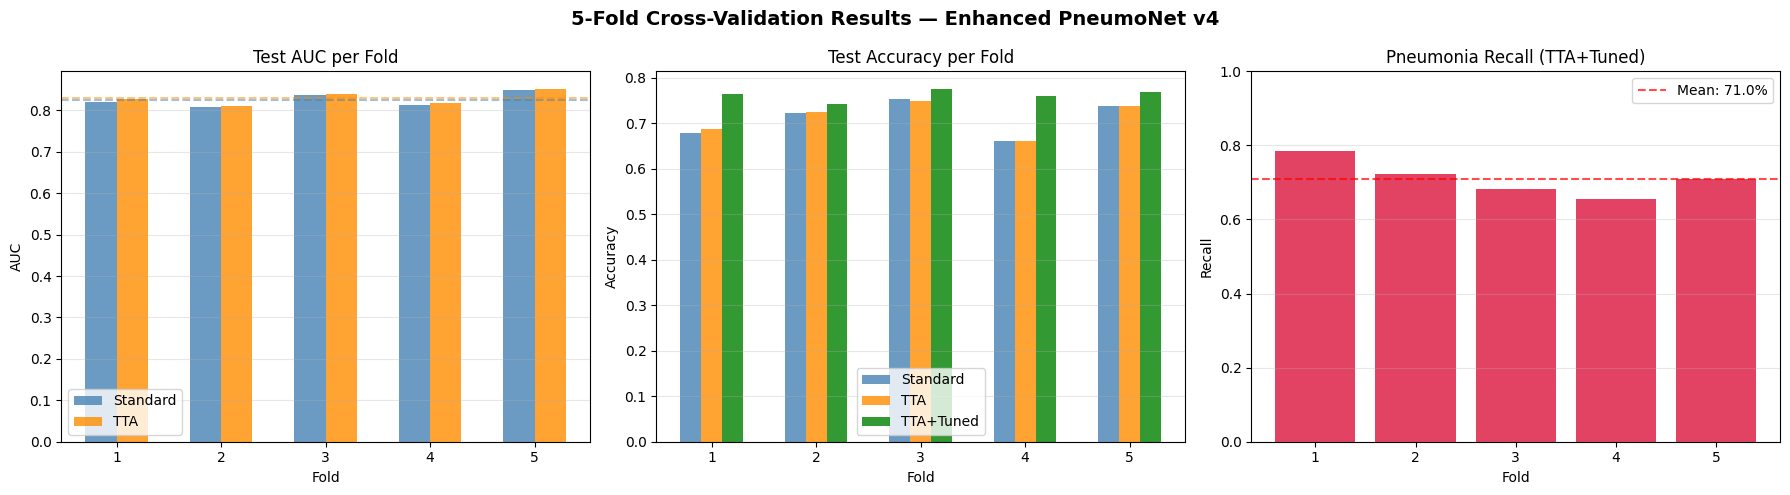

In [13]:
# --- CELL 12: Visualizations ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('5-Fold Cross-Validation Results — Enhanced PneumoNet v4', fontsize=14, fontweight='bold')

folds = [r['fold'] for r in fold_results]

# AUC comparison
ax = axes[0]
ax.bar(np.array(folds) - 0.15, [r['test_auc'] for r in fold_results], width=0.3, label='Standard', color='steelblue', alpha=0.8)
ax.bar(np.array(folds) + 0.15, [r['tta_auc'] for r in fold_results], width=0.3, label='TTA', color='darkorange', alpha=0.8)
ax.axhline(results_df['test_auc'].mean(), color='steelblue', ls='--', alpha=0.5)
ax.axhline(results_df['tta_auc'].mean(), color='darkorange', ls='--', alpha=0.5)
ax.set_xlabel('Fold'); ax.set_ylabel('AUC'); ax.set_title('Test AUC per Fold')
ax.set_xticks(folds); ax.legend(); ax.grid(alpha=0.3, axis='y')

# Accuracy comparison
ax = axes[1]
ax.bar(np.array(folds) - 0.2, [r['test_acc'] for r in fold_results], width=0.2, label='Standard', color='steelblue', alpha=0.8)
ax.bar(np.array(folds),       [r['tta_acc'] for r in fold_results], width=0.2, label='TTA', color='darkorange', alpha=0.8)
ax.bar(np.array(folds) + 0.2, [r['tuned_acc'] for r in fold_results], width=0.2, label='TTA+Tuned', color='green', alpha=0.8)
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy'); ax.set_title('Test Accuracy per Fold')
ax.set_xticks(folds); ax.legend(); ax.grid(alpha=0.3, axis='y')

# Pneumonia recall
ax = axes[2]
ax.bar(folds, [r['pn_recall'] for r in fold_results], color='crimson', alpha=0.8)
ax.axhline(results_df['pn_recall'].mean(), color='red', ls='--', alpha=0.7, label=f'Mean: {results_df["pn_recall"].mean():.1%}')
ax.set_xlabel('Fold'); ax.set_ylabel('Recall'); ax.set_title('Pneumonia Recall (TTA+Tuned)')
ax.set_xticks(folds); ax.legend(); ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cv_results_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()

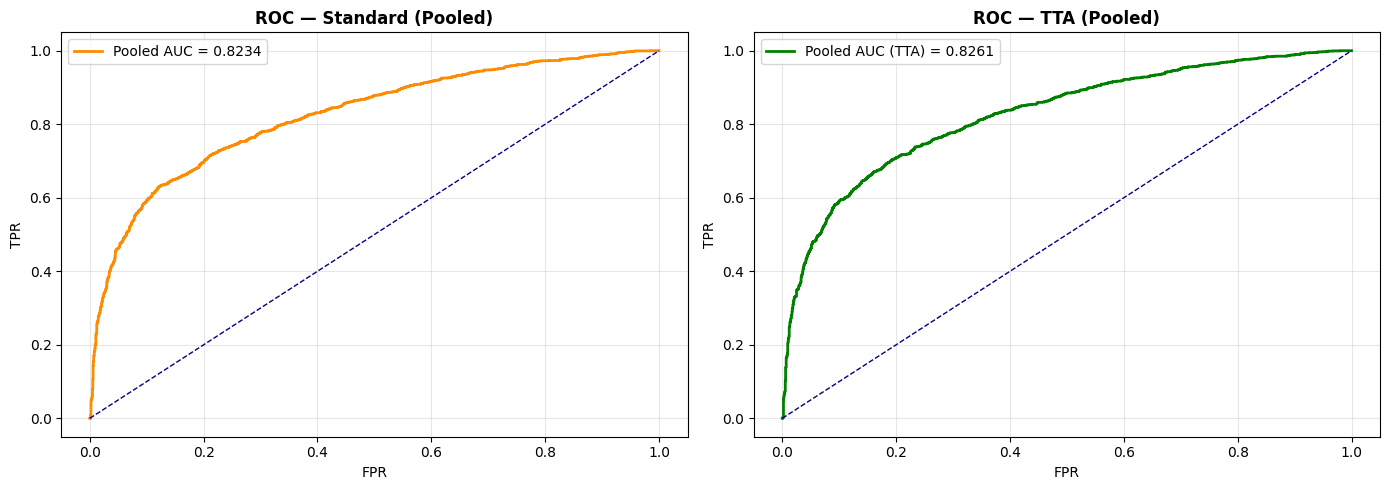

In [14]:
# --- CELL 13: Pooled ROC Curve ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Standard ROC
fpr, tpr, _ = roc_curve(all_test_labels, all_test_probs)
ax = axes[0]
ax.plot(fpr, tpr, lw=2, color='darkorange', label=f'Pooled AUC = {roc_auc_score(all_test_labels, all_test_probs):.4f}')
ax.plot([0,1],[0,1],'navy',ls='--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC — Standard (Pooled)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# TTA ROC
fpr_tta, tpr_tta, _ = roc_curve(all_test_labels_tta, all_test_probs_tta)
ax = axes[1]
ax.plot(fpr_tta, tpr_tta, lw=2, color='green', label=f'Pooled AUC (TTA) = {roc_auc_score(all_test_labels_tta, all_test_probs_tta):.4f}')
ax.plot([0,1],[0,1],'navy',ls='--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC — TTA (Pooled)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'pooled_roc_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

In [15]:
# --- CELL 14: Save Final Config ---
final_config = {
    'n_folds': N_FOLDS,
    'tta_views': TTA_TRANSFORMS,
    'mean_test_auc': float(results_df['test_auc'].mean()),
    'std_test_auc': float(results_df['test_auc'].std()),
    'mean_tta_auc': float(results_df['tta_auc'].mean()),
    'std_tta_auc': float(results_df['tta_auc'].std()),
    'mean_tuned_acc': float(results_df['tuned_acc'].mean()),
    'std_tuned_acc': float(results_df['tuned_acc'].std()),
    'mean_pn_recall': float(results_df['pn_recall'].mean()),
    'std_pn_recall': float(results_df['pn_recall'].std()),
    'pooled_auc_standard': float(roc_auc_score(all_test_labels, all_test_probs)),
    'pooled_auc_tta': float(roc_auc_score(all_test_labels_tta, all_test_probs_tta)),
    'fold_details': fold_results,
}

with open(os.path.join(SAVE_DIR, 'v4_config.json'), 'w') as f:
    json_lib.dump(final_config, f, indent=2)

print('\n✅ Phase 1.1v4 COMPLETE.')
print(f'Results saved to: {SAVE_DIR}')
print(f'\nKey Metrics (mean ± std across {N_FOLDS} folds):')
print(f'  Test AUC      : {results_df["test_auc"].mean():.4f} ± {results_df["test_auc"].std():.4f}')
print(f'  TTA AUC       : {results_df["tta_auc"].mean():.4f} ± {results_df["tta_auc"].std():.4f}')
print(f'  Tuned Accuracy: {results_df["tuned_acc"].mean():.4f} ± {results_df["tuned_acc"].std():.4f}')
print(f'  Pn Recall     : {results_df["pn_recall"].mean():.1%} ± {results_df["pn_recall"].std():.1%}')


✅ Phase 1.1v4 COMPLETE.
Results saved to: c:\2026\PneumoFusionNet\mimic\main\dataset\outputs\Phase_1.1v4_PA_crossval_scaleup

Key Metrics (mean ± std across 5 folds):
  Test AUC      : 0.8258 ± 0.0171
  TTA AUC       : 0.8290 ± 0.0167
  Tuned Accuracy: 0.7626 ± 0.0127
  Pn Recall     : 71.0% ± 4.8%


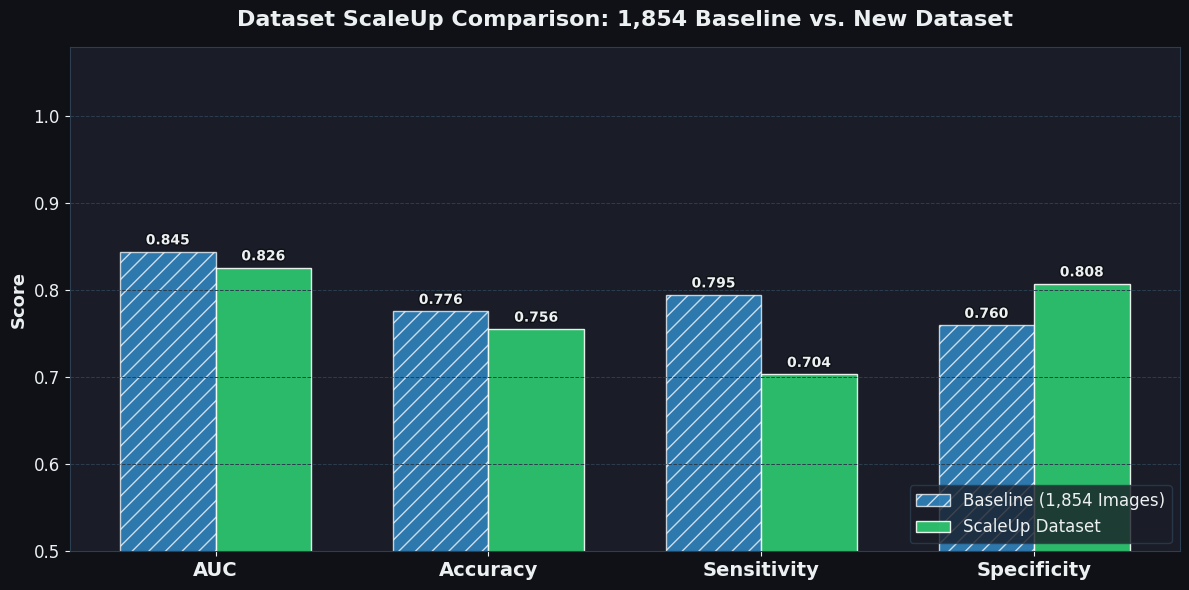


=== Dataset ScaleUp Impact ===
Metric          Baseline (1,854)    ScaleUp Dataset   Difference
-----------------------------------------------------------------
AUC                       0.8445             0.8261      -1.8%
Accuracy                  0.7760             0.7556      -2.0%
Sensitivity               0.7950             0.7035      -9.1%
Specificity               0.7600             0.8077     +4.8%


: 

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

# 1. Hardcoded Baseline Metrics (From your original 1,854 image Phase 1.1v4 Fold 2)
baseline_v = [
    0.8445,   # AUC
    0.7760,   # Accuracy
    0.7950,   # Sensitivity
    0.7600    # Specificity
]

# 2. Grab the live ScaleUp metrics from the cell we just ran above!
scaleup_v = [
    scaleup_auc,  # Live ScaleUp AUC
    acc_t,        # Live ScaleUp Accuracy
    sens_t,       # Live ScaleUp Sensitivity
    spec_t        # Live ScaleUp Specificity
]

metrics_names = ['AUC', 'Accuracy', 'Sensitivity', 'Specificity']
x = np.arange(len(metrics_names))
w = 0.35

# Plot Styling
BG = '#0f1117'; AX = '#1a1d27'; TC = '#ecf0f1'; GC = '#2c3e50'
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(AX)
ax.spines[:].set_color(GC)
ax.tick_params(colors=TC, labelsize=12)

# Create Bars
b1 = ax.bar(x - w/2, baseline_v, w, color='#3498db', edgecolor='white', alpha=0.75, hatch='//', label='Baseline (1,854 Images)')
b2 = ax.bar(x + w/2, scaleup_v,  w, color='#2ecc71', edgecolor='white', alpha=0.90, label='ScaleUp Dataset')

# Add exact value labels on top of bars
for bars in [b1, b2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color=TC,
                path_effects=[pe.withStroke(linewidth=2, foreground=BG)])

# Gridlines & Labels
for yv in [0.6, 0.7, 0.8, 0.9, 1.0]:
    ax.axhline(yv, color=GC, lw=0.7, linestyle='--', zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=14, fontweight='bold', color=TC)
ax.set_ylim(0.50, 1.08)
ax.set_ylabel('Score', fontsize=13, color=TC, fontweight='bold')
ax.set_title('Dataset ScaleUp Comparison: 1,854 Baseline vs. New Dataset', fontsize=16, fontweight='bold', color=TC, pad=15)
ax.legend(fontsize=12, facecolor=AX, edgecolor=GC, labelcolor=TC, loc='lower right')

plt.tight_layout()
plt.show()

# Print Table Format for easy copying
print("\n=== Dataset ScaleUp Impact ===")
print(f"{'Metric':15s} {'Baseline (1,854)':>16s} {'ScaleUp Dataset':>18s} {'Difference':>12s}")
print("-" * 65)
for m, v1, v2 in zip(metrics_names, baseline_v, scaleup_v):
    diff = (v2 - v1) * 100
    sign = "+" if diff >= 0 else ""
    print(f"{m:15s} {v1:>16.4f} {v2:>18.4f} {sign:>5s}{diff:.1f}%")

In [1]:
# Confusion Matrix for pooled TTA predictions

probs = np.array(all_test_probs_tta if 'all_test_probs_tta' in globals() else all_test_probs)
labels = np.array(all_test_labels_tta if 'all_test_labels_tta' in globals() else all_test_labels)

thr = find_optimal_threshold(labels, probs)
preds = (probs >= thr).astype(int)

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=CLASSES, yticklabels=CLASSES
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (threshold={thr:.4f})')
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined